<a href="https://colab.research.google.com/github/AzizaZaman101/RT-IoT2022_Multi-Class_IoT_Attack_Detection_ML/blob/main/notebooks/RT_IoT2022_Multi_Class_IoT_Attack_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project showcases the machine learning pipeline for multi-class classification of IoT network traffic using the ***RT-IoT2022 dataset*** - as suggested in the project requirements.

## 1. Introduction

## 2. Import Libraries

In [35]:
import pandas as pd # works with tables and structured data --> dataframe
import numpy as np # highly optimized numerical operations
import matplotlib.pyplot as plt # plotting library
import seaborn as sns # for statistical visualization


In [36]:
from google.colab import files # makes colabs file upload functionalities into python

## 3. Dataset Loading

In [37]:
uploaded = files.upload() # to search for files/zip of files that we want to upload from the computer

Saving rt-iot2022.zip to rt-iot2022 (1).zip


In [38]:
import zipfile # works with zip archive

zip_filename = list(uploaded.keys())[0] # to give the name of the first uploaded file name

with zipfile.ZipFile(zip_filename, 'r') as zip_ref: # 'r' is the zip file reference to drive
    print(zip_ref.namelist())

['RT_IOT2022']


In [39]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    for info in zip_ref.infolist():
        print("Name:", info.filename)
        print("Is directory:", info.is_dir())
        print() # finding the .csv file inside the folder which is inside the zip file

Name: RT_IOT2022
Is directory: False



## 4. Dataset Understanding

In [40]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    info = zip_ref.getinfo('RT_IOT2022')

    print("File name:", info.filename)
    print("File size:", info.file_size, "bytes")
    print("Compressed size:", info.compress_size, "bytes")

File name: RT_IOT2022
File size: 54781794 bytes
Compressed size: 3445425 bytes


In [41]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    with zip_ref.open('RT_IOT2022') as file:
        for i in range(5):
            line = file.readline()
            print(line.decode('utf-8', errors='replace').rstrip())

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,pa

In [42]:
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    with zip_ref.open('RT_IOT2022') as file:
        df = pd.read_csv(file, index_col=0) # first column of original file as row index, hence the row numbers in the first column

In [43]:
df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [44]:
df.shape # how big is the dataset

(123117, 84)

In [45]:
for i, column in enumerate(df.columns, start=1): # to check how many columns we have
    print(i, column)

1 id.orig_p
2 id.resp_p
3 proto
4 service
5 flow_duration
6 fwd_pkts_tot
7 bwd_pkts_tot
8 fwd_data_pkts_tot
9 bwd_data_pkts_tot
10 fwd_pkts_per_sec
11 bwd_pkts_per_sec
12 flow_pkts_per_sec
13 down_up_ratio
14 fwd_header_size_tot
15 fwd_header_size_min
16 fwd_header_size_max
17 bwd_header_size_tot
18 bwd_header_size_min
19 bwd_header_size_max
20 flow_FIN_flag_count
21 flow_SYN_flag_count
22 flow_RST_flag_count
23 fwd_PSH_flag_count
24 bwd_PSH_flag_count
25 flow_ACK_flag_count
26 fwd_URG_flag_count
27 bwd_URG_flag_count
28 flow_CWR_flag_count
29 flow_ECE_flag_count
30 fwd_pkts_payload.min
31 fwd_pkts_payload.max
32 fwd_pkts_payload.tot
33 fwd_pkts_payload.avg
34 fwd_pkts_payload.std
35 bwd_pkts_payload.min
36 bwd_pkts_payload.max
37 bwd_pkts_payload.tot
38 bwd_pkts_payload.avg
39 bwd_pkts_payload.std
40 flow_pkts_payload.min
41 flow_pkts_payload.max
42 flow_pkts_payload.tot
43 flow_pkts_payload.avg
44 flow_pkts_payload.std
45 fwd_iat.min
46 fwd_iat.max
47 fwd_iat.tot
48 fwd_iat.avg
49 fw

In [46]:
column_info = pd.DataFrame({ # to create a proper column table
    'Column_Number': range(1, len(df.columns) + 1),
    'Column_Name': df.columns,
    'Data_Type': df.dtypes.astype(str).values
})

column_info

,Column_Number,Column_Name,Data_Type
0,1,id.orig_p,int64
1,2,id.resp_p,int64
2,3,proto,object
3,4,service,object
4,5,flow_duration,float64
...,...,...,...
79,80,idle.std,float64
80,81,fwd_init_window_size,int64
81,82,bwd_init_window_size,int64
82,83,fwd_last_window_size,int64


In [47]:
dataset_summary = pd.DataFrame({ # making a dataframe to check all the columns values, missing values, nunique values, etc
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str).values,
    'Missing_Values': df.isnull().sum().values,
    'Unique_Values': df.nunique().values,
})

dataset_summary

,Column,Data_Type,Missing_Values,Unique_Values
0,id.orig_p,int64,0,65478
1,id.resp_p,int64,0,1809
2,proto,object,0,3
3,service,object,0,10
4,flow_duration,float64,0,16383
...,...,...,...,...
79,idle.std,float64,0,1001
80,fwd_init_window_size,int64,0,20
81,bwd_init_window_size,int64,0,56
82,fwd_last_window_size,int64,0,109


In [48]:
print("Numerical columns:") # checking how many columns hold numerical values
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical/text columns:")  # checking how many columns hold categorical values
print(df.select_dtypes(exclude='number').columns.tolist())

Numerical columns:
['id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.av

we are currently kind of sure that Attack_type is out target variable - meaning the variables value we want to predict.

In [49]:
df['Attack_type'].unique() # how many unique values are there under this variable

array(['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb', 'ARP_poisioning',
       'DDOS_Slowloris', 'DOS_SYN_Hping', 'Metasploit_Brute_Force_SSH',
       'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan',
       'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN'], dtype=object)

In [50]:
df['Attack_type'].value_counts() # counts every class

,count
Attack_type,
DOS_SYN_Hping,94659
Thing_Speak,8108
ARP_poisioning,7750
MQTT_Publish,4146
NMAP_UDP_SCAN,2590
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,534


### Plot The Target Variable

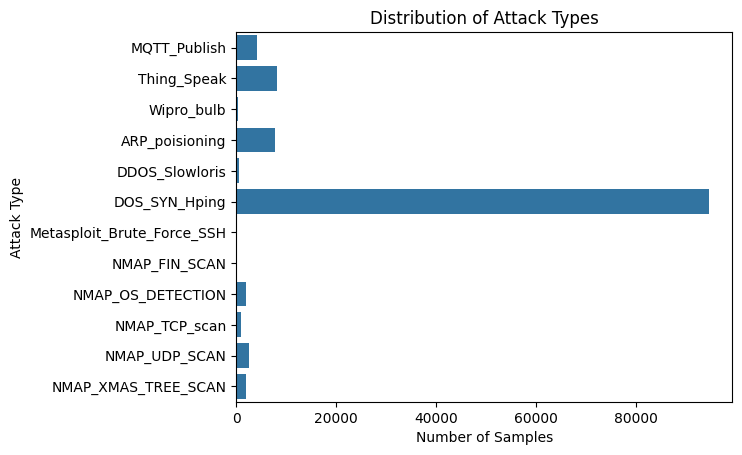

In [51]:
sns.countplot(data=df, y='Attack_type')
plt.title('Distribution of Attack Types')
plt.xlabel('Number of Samples')
plt.ylabel('Attack Type')
plt.show()

This dataset is strongly imbalanced, as there are no equal distribution noticeable in the dataset. We can understand from here, splitting the data randomly would give better accuracy but leave the rarest attack types alone. So, we might have to work with weighted F1 score in the dataset in the next steps.

## 5. Data Cleaning

## 6. Data Analysis

## 7. Data Preprocessing

## 8. Train/Validation/Test/Split

## 9. Model 1

## 10. Model 2

## 11. Model 3

## 12. Model Comparison

## 13. Confusion Matrix Analysis


## 14. Best Model Selection

## 15. Limitations


## 16. Conclusion
